# DATA 620 Project 2
## Kevin Havis & Aaliyah John-Harry

In [56]:
import nltk
import pandas as pd
import re
from collections import Counter
from nltk.corpus import gutenberg
import matplotlib.pyplot as plt
import numpy as np

## 1. Choose a corpus of interest.

We've chose Jane Austen's *Emma* from the Gutenberg library available in NTLK as our corpus.

> Emma is a novel written by English author Jane Austen. It is set in the fictional Surrey village of Highbury and the surrounding estates of Hartfield, Randalls, and Donwell Abbey, and involves the relationships among people from a small number of families. The novel was first published in December 1815, although the title page is dated 1816. As in her other novels, Austen explores the concerns and difficulties of genteel women living in Georgian–Regency England. Emma is a comedy of manners

[Wikipedia](https://en.wikipedia.org/wiki/Emma_(novel))

In [57]:
words = gutenberg.words("austen-emma.txt")
clean_words = [w.lower() for w in words if re.match("^[a-zA-Z]+$", w)]

## 2. How many total unique words are in the corpus?

We can do this easily with Python's base libraries.

In [58]:
total_words = len(clean_words)
word_counts = Counter(clean_words)
unique_words = len(word_counts)

print("Total words:", total_words)
print("Unique words:", unique_words)

Total words: 161600
Unique words: 7079


## 3. Taking the most common words, how many unique words represent half of the total words in the corpus?

We first sort the words by their frequency, then take the top half and check how many distinct values are in that subset.

In [59]:
sorted_counts = word_counts.most_common()

cumulative = 0
half_total = total_words / 2

num_words_50 = 0

for word, count in sorted_counts:
    cumulative += count
    num_words_50 += 1
    if cumulative >= half_total:
        break

print(
    "Number of unique high-frequency words needed to account for half of the corpus:",
    num_words_50,
)

Number of unique high-frequency words needed to account for half of the corpus: 56


## 4. Identify the 200 highest frequency words in this corpus.

Since we've already sorted the words, we can simply take the top 200 directly, and create a dataframe to further process

In [60]:
top_200 = sorted_counts[:200]

df_top_200 = pd.DataFrame(top_200, columns=["Word", "Frequency"])
df_top_200

,Word,Frequency
0,to,5239
1,the,5201
2,and,4896
3,of,4291
4,i,3178
...,...,...
195,saw,108
196,few,106
197,myself,103
198,till,102


## 5. Create a graph that shows the relative frequency of these 200 words

We have two options for frequency typically with word charts; the typical frequency or bar plot, or word clouds.

We find bar charts to be more intuitive and easier to read, so we've plotted each of the top 200 words by their frequency. Using "lollipop" style markers make it more legible.

Unsurprisingly, stop words are the most common.

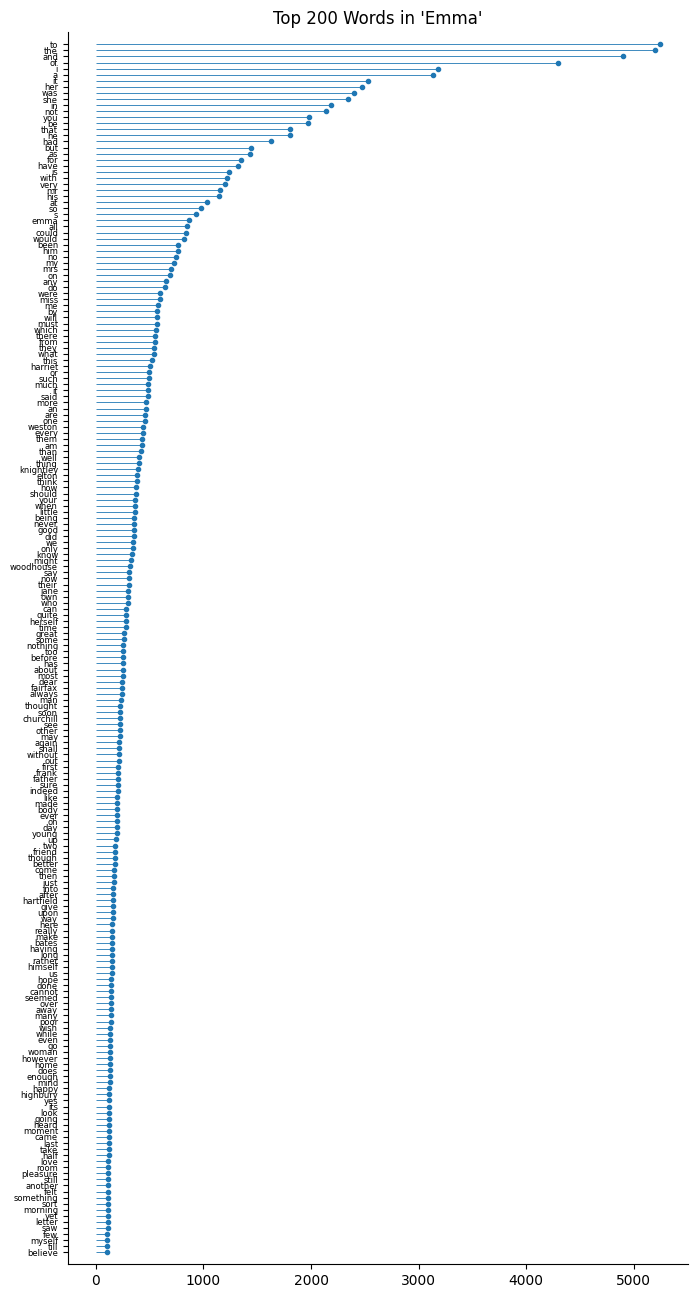

In [61]:
fig, ax = plt.subplots(figsize=(8, 16))

ax.hlines(df_top_200["Word"], 0, df_top_200["Frequency"], linewidth=0.6)
ax.plot(df_top_200["Frequency"], df_top_200["Word"], "o", markersize=3)
ax.tick_params(axis="y", labelsize=6)
ax.invert_yaxis()
ax.set_title("Top 200 Words in 'Emma'")
ax.margins(y=0.01)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

## 6. Does the observed relative frequency of these words follow Zipf's law?

Zipf's law is essentially a Power Law, stating that when sorted, a series of frequencies is inversely proportional to the rank.

In other words, as rank increases (which is typically represented as decreasing, given we associate rank 1 with being the highest), frequency should decrease at a non-linear rate.

We can prove that our frequency distribution follows this law quite simply by superimposing the function of Zipf's law over our previous plot (another good reason for choosing barplots).

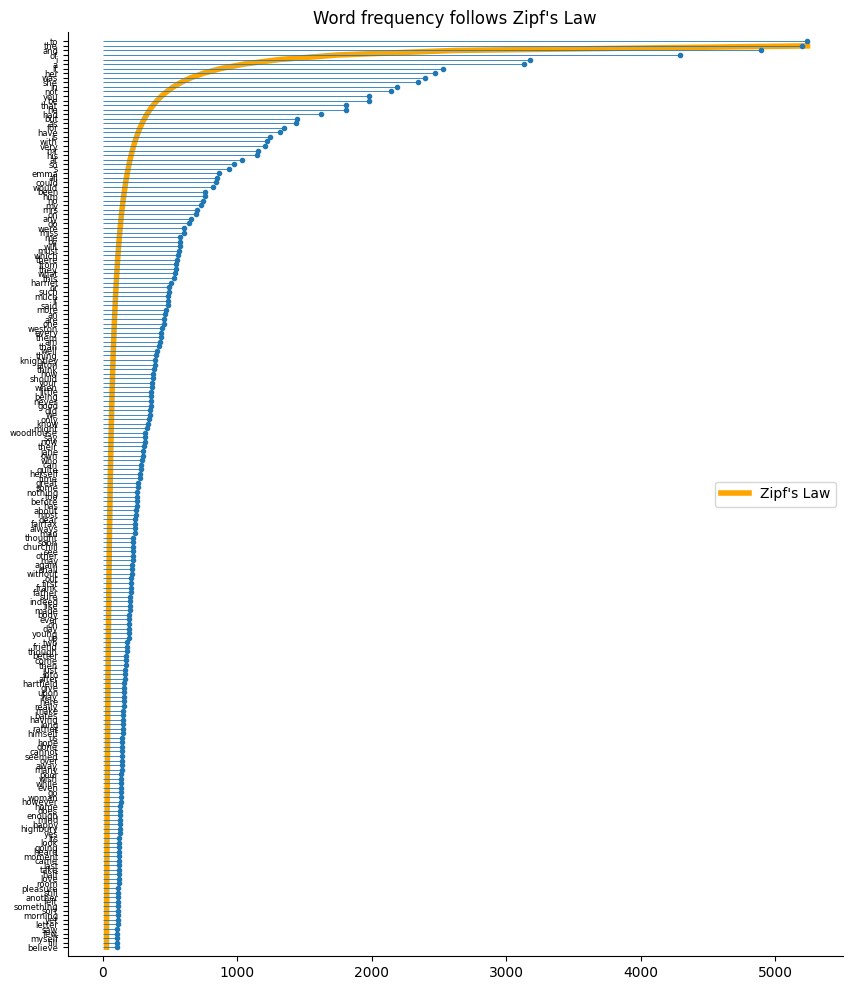

In [62]:
import numpy as np

frequencies = df_top_200.Frequency.values

# Our index is sorted by frequency so use it for rank
ranks = df_top_200.index
# Frequency is the ratio of the largest frequency divided by each rank
zipf_freqs = frequencies[0] / ranks


fig, ax = plt.subplots(figsize=(10, 12))
# Plot Zipf's
ax.plot(
    zipf_freqs, ranks, color="orange", linewidth=4, label="Zipf's Law"
)  # flip axes to match your horizontal bar chart orientation
# Plot our frequencies
ax.hlines(df_top_200["Word"], 0, df_top_200["Frequency"], linewidth=0.6)
ax.plot(df_top_200["Frequency"], df_top_200["Word"], "o", markersize=3)
ax.tick_params(axis="y", labelsize=6)
ax.invert_yaxis()
ax.set_title("Word frequency follows Zipf's Law")
ax.margins(y=0.01)
ax.legend(loc="center right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

## 7. In what ways do you think the frequency of the words in this corpus differs from "all words in all corpora"?

We alluded to the key difference in our corpus earlier; while **stop words** such as `to`, `the`, `and`, `of` will typically be seen in almost every natural language corpus as ranking very high by frequency, the unique elements in a book such as Jane Austen's *Emma* are typically the characters, places, or other nouns.

This holds true in our plots - we see the top words by frequency are all stop words, but the names of main characters such as `emma`, `woodhouse`, and `knightley` still make it into the top 200. We can also see gendered pronouns `she` and `her` being very highly ranked, which gives us the indication that the main character is a woman (if the title didn't give that away already!).

This is why many NLP analyses benefit from the removal of stop words and lemmatization - it allows us to filter through the noise and focus on what's truly unique in the document.